<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part I · Foundations &nbsp;|&nbsp; Chapter 7</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Math Refresher for Statistics <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:720px;line-height:1.6">Six bite-sized demos covering exactly the math you need: summation, sets, counting, logarithms, a pinch of calculus, and the linear algebra of data, each tied straight to statistics.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

> ### 🎯 What you'll build in this notebook
>
> | # | Demo | Statistics it powers |
> |---|------|----------------------|
> | 1 | Summation Σ → mean &amp; variance | Reading every stats formula |
> | 2 | Sets &amp; a Venn diagram | Probability rules |
> | 3 | Permutations &amp; combinations | Counting &amp; odds |
> | 4 | Logarithms | Log scales, likelihood |
> | 5 | A pinch of calculus | Optimization / model training |
> | 6 | Vectors &amp; matrices | Data as a table the computer can crunch |

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"
GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
    "axes.edgecolor":GRID,"axes.linewidth":1.2,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,
    "axes.spines.top":False,"axes.spines.right":False,"axes.titlesize":15,"axes.titleweight":"bold","axes.titlecolor":INK,
    "axes.labelcolor":INK_SOFT,"axes.labelsize":11.5,"xtick.color":INK_SOFT,"ytick.color":INK_SOFT,"legend.frameon":False,
})
def titlecard(ax, title, subtitle=None):
    ax.set_title(title, loc="left", pad=18)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=10.5, color=INK_SOFT, va="bottom")
print("✅ Environment ready.")

✅ Environment ready.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · SUMMATION (Σ)</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">➕ The symbol behind every stats formula</div>
<div style="color:#4a5578;margin-top:6px">Σ just means "add them all up." The mean is (1/n)·Σxᵢ and the variance is (1/n)·Σ(xᵢ−mean)². Let's prove the formulas equal NumPy.</div>
</div>

In [2]:
x = np.array([4, 8, 6, 5, 3, 9, 7])
n = len(x)

# Mean from the formula:  x̄ = (1/n) Σ xᵢ
mean_formula = x.sum() / n

# Variance from the formula:  σ² = (1/n) Σ (xᵢ − x̄)²
var_formula = ((x - mean_formula)**2).sum() / n

print(f"Σ xᵢ            = {x.sum()}")
print(f"mean (formula)  = {mean_formula:.3f}   |  np.mean = {np.mean(x):.3f}")
print(f"var  (formula)  = {var_formula:.3f}   |  np.var  = {np.var(x):.3f}")
print("\nThe Greek Σ is just a for-loop that adds things up.")

Σ xᵢ            = 42
mean (formula)  = 6.000   |  np.mean = 6.000
var  (formula)  = 4.000   |  np.var  = 4.000

The Greek Σ is just a for-loop that adds things up.


<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · SETS & VENN DIAGRAMS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔵 The language of probability</div>
<div style="color:#4a5578;margin-top:6px">Events are sets. Union (A∪B = "A or B"), intersection (A∩B = "A and B"), and difference power the probability rules in Part V.</div>
</div>

In [3]:
A = {2, 4, 6, 8, 10}
B = {3, 6, 9}
print("A ∪ B (union)        =", A | B)
print("A ∩ B (intersection) =", A & B)
print("A − B (difference)   =", A - B)

A ∪ B (union)        = {2, 3, 4, 6, 8, 9, 10}
A ∩ B (intersection) = {6}
A − B (difference)   = {8, 2, 10, 4}


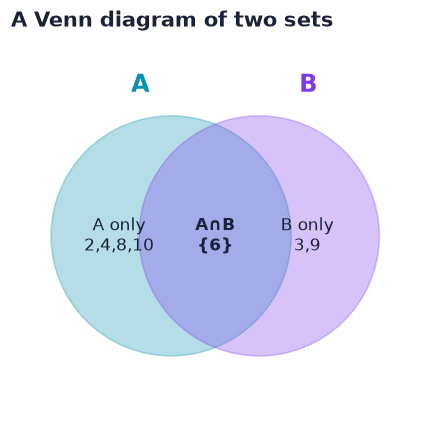

In [4]:
fig, ax = plt.subplots(figsize=(7.5,4.2))
ax.add_patch(plt.Circle((0.40,0.5), 0.30, color=CYAN,   alpha=0.30))
ax.add_patch(plt.Circle((0.62,0.5), 0.30, color=PURPLE, alpha=0.30))
ax.text(0.27,0.5, "A only\n2,4,8,10", ha="center", va="center", fontsize=11, color=INK)
ax.text(0.51,0.5, "A∩B\n{6}", ha="center", va="center", fontsize=11, fontweight="bold", color=INK)
ax.text(0.74,0.5, "B only\n3,9", ha="center", va="center", fontsize=11, color=INK)
ax.text(0.30,0.86,"A", fontsize=16, fontweight="bold", color=CYAN)
ax.text(0.72,0.86,"B", fontsize=16, fontweight="bold", color=PURPLE)
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect("equal"); ax.axis("off")
ax.set_title("A Venn diagram of two sets", loc="left", fontsize=14)
plt.tight_layout(); plt.show()

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · PERMUTATIONS & COMBINATIONS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔢 Counting the possibilities</div>
<div style="color:#4a5578;margin-top:6px">Permutations count arrangements (order matters); combinations count selections (order doesn't). This is the backbone of probability and the binomial distribution.</div>
</div>

In [5]:
# From 5 people, arrange 3 in a row (order matters) -> PERMUTATIONS
print(f"Permutations  P(5,3) = {math.perm(5,3)}  (order matters)")

# From 5 people, choose a committee of 3 (order does NOT matter) -> COMBINATIONS
print(f"Combinations  C(5,3) = {math.comb(5,3)}  (order does not matter)")

# Real odds: a 6-from-49 lottery
ways = math.comb(49, 6)
print(f"\nLottery: choose 6 numbers from 49 -> {ways:,} combinations")
print(f"Your chance of winning: 1 in {ways:,}")

Permutations  P(5,3) = 60  (order matters)
Combinations  C(5,3) = 10  (order does not matter)

Lottery: choose 6 numbers from 49 -> 13,983,816 combinations
Your chance of winning: 1 in 13,983,816


<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 4 · LOGARITHMS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📐 Taming huge numbers & products</div>
<div style="color:#4a5578;margin-top:6px">Logs turn multiplication into addition and squeeze enormous ranges onto a readable scale, used everywhere from log-likelihood to log-scale charts.</div>
</div>

log(a·b)        = 11.5129
log(a) + log(b) = 11.5129  ← same! products become sums


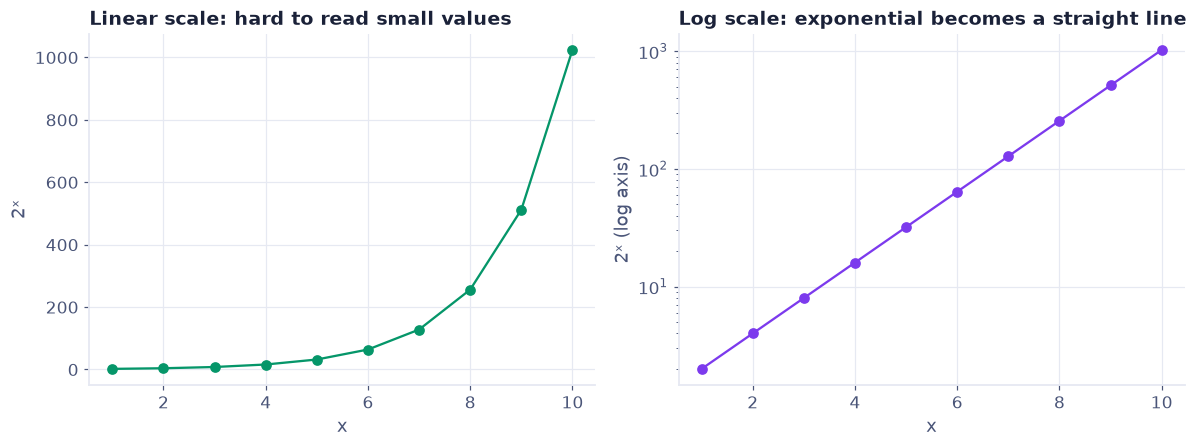

In [6]:
a, b = 1000, 100
print("log(a·b)        =", round(np.log(a*b), 4))
print("log(a) + log(b) =", round(np.log(a) + np.log(b), 4), " ← same! products become sums")

# Why a log scale helps: exponential growth looks linear on a log axis
x = np.arange(1, 11)
y = 2.0**x                      # 2, 4, 8, ... 1024 (explodes)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11,4.2))
a1.plot(x, y, "o-", color=GREEN); a1.set_title("Linear scale: hard to read small values", loc="left", fontsize=12.5)
a1.set_xlabel("x"); a1.set_ylabel("2ˣ")
a2.plot(x, y, "o-", color=PURPLE); a2.set_yscale("log")
a2.set_title("Log scale: exponential becomes a straight line", loc="left", fontsize=12.5)
a2.set_xlabel("x"); a2.set_ylabel("2ˣ (log axis)")
plt.tight_layout(); plt.show()

<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 5 · A PINCH OF CALCULUS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📉 Slopes that find the minimum</div>
<div style="color:#4a5578;margin-top:6px">A derivative is the slope of a curve. Setting the slope toward zero is how models "learn", here we minimize a simple loss with gradient descent (the engine of ML training).</div>
</div>

Started at x=0, slid to x=2.996  (true minimum is x=3)


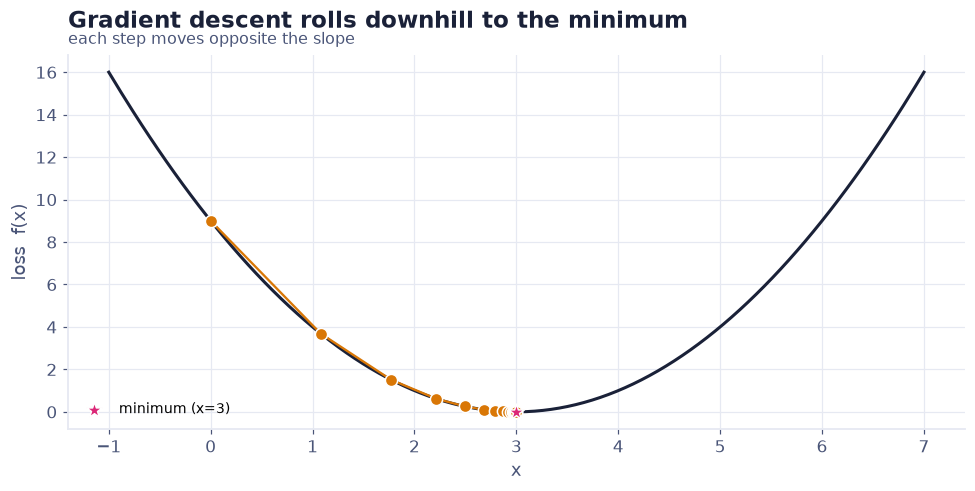

In [7]:
# Minimize the loss  f(x) = (x − 3)²   whose derivative is  f'(x) = 2(x − 3)
f    = lambda x: (x - 3)**2
grad = lambda x: 2*(x - 3)

x = 0.0; lr = 0.18; path = [x]
for _ in range(15):
    x = x - lr*grad(x)     # step downhill, opposite the slope
    path.append(x)
path = np.array(path)
print(f"Started at x=0, slid to x={path[-1]:.3f}  (true minimum is x=3)")

xs = np.linspace(-1, 7, 200)
fig, ax = plt.subplots(figsize=(9,4.6))
ax.plot(xs, f(xs), color=INK, lw=2)
ax.plot(path, f(path), "o-", color=AMBER, markersize=8, markeredgecolor="white", lw=1.5)
ax.scatter([3],[0], color=PINK, s=120, zorder=5, marker="*", edgecolor="white", label="minimum (x=3)")
titlecard(ax, "Gradient descent rolls downhill to the minimum", "each step moves opposite the slope")
ax.set_xlabel("x"); ax.set_ylabel("loss  f(x)"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

<div style="background:#fce7f3;border-left:5px solid #db2777;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#db2777;letter-spacing:1px">DEMO 6 · VECTORS & MATRICES</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔢 Data is a matrix</div>
<div style="color:#4a5578;margin-top:6px">A dataset is just a grid of numbers, a matrix (rows = records, columns = features). Linear algebra lets the computer crunch the whole table at once.</div>
</div>

In [8]:
# Rows = people, columns = [height_cm, weight_kg]  → a 4×2 matrix
X = np.array([[170, 70],
              [160, 55],
              [180, 82],
              [175, 77]])
print("Data matrix X (shape", X.shape, "):")
print(X)

# Column means in ONE operation (no loop)
print("\nMean of each column [height, weight]:", X.mean(axis=0))

# Matrix × vector: combine columns with weights (e.g., a simple body index)
weights = np.array([0.5, 1.0])
scores = X @ weights          # the @ operator is matrix multiplication
print("\nX @ weights  (one weighted score per person):", scores)

Data matrix X (shape (4, 2) ):
[[170  70]
 [160  55]
 [180  82]
 [175  77]]

Mean of each column [height, weight]: [171.25  71.  ]

X @ weights  (one weighted score per person): [155.  135.  172.  164.5]


Every model in this book ultimately runs on matrices like `X`, linear algebra is how statistics scales from a handful of rows to millions.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap, the math toolkit</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li><b>Σ (summation)</b> is "add them all up", the heart of mean and variance.</li>
<li><b>Sets</b> (∪, ∩) are the language of probability events.</li>
<li><b>Permutations vs combinations</b> count arrangements vs selections.</li>
<li><b>Logarithms</b> turn products into sums and tame huge ranges.</li>
<li><b>Derivatives</b> are slopes, gradient descent uses them to train models.</li>
<li><b>Matrices</b> hold your data so it can all be computed at once.</li>
</ul>
<div style="margin-top:12px;padding-top:12px;border-top:1px dashed #e6e9f2;color:#7c3aed;font-weight:700">That wraps Part I, Foundations. Next: Part II, where we start describing data.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>